This notebook calculates along-slope ocean velocity for two SO6-family simulations and compares them side-by-side:

- **SO6** (BSOSE Iteration 168, physics-only): `/data/SOSE/SOSE/SO6/ITER168/MONTHLY/`
- **BGOSE6** (BSOSE Iteration 41, with biogeochemistry): `/data/SOSE/SOSE/BGOSE6/ITER041/MONTHLY/`

Both are restricted to poleward of 50°S, the common overlapping time period, and depths of 0–1200 m. Outputs per simulation:

1. `u_along_0_500`, along-slope velocity vertically averaged from 0–500 m.
2. `u_along_0_1200m`, along-slope velocity at all retained depths (0–1200 m).
3. `bathym`, bathymetry on the velocity grid.

In [1]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter
from matplotlib.path import Path
from datetime import datetime, timezone
%matplotlib inline

In [ ]:
# Spin up a local dask cluster FIRST — must run before any .persist() or .compute() call.
# Without an active client, .persist() falls back to single-threaded local execution.
#
# Teardown guard: re-running this cell closes any existing cluster cleanly,
# so it is safe to re-run after an interrupt or a hung computation.
# If a compute hangs and workers are still responsive, client.restart() is
# faster than a full kernel restart.

from dask.distributed import Client, LocalCluster, wait

try:
    client.close()
    cluster.close()
    print('Previous cluster closed.')
except NameError:
    pass

cluster = LocalCluster()
client  = Client(cluster)
print(client)
print('Dashboard:', client.dashboard_link)

Previous cluster closed.
<Client: 'tcp://127.0.0.1:41263' processes=16 threads=128, memory=0.98 TiB>
Dashboard: http://127.0.0.1:8787/status


2026-06-01 17:29:05,394 - distributed.semaphore - WARNING - Tried to release Lock or Semaphore but it was already released: name='/data/globus/zkaufman/u_along_0_1200m_SO6_201301to202112_monthly.nc', lease_id='33bea9a2adac43f4b0810b4334b20772'. This can happen if the Lock or Semaphore timed out before.
2026-06-01 17:29:35,033 - distributed.semaphore - WARNING - Tried to release Lock or Semaphore but it was already released: name='/data/globus/zkaufman/u_along_0_1200m_SO6_201301to202112_monthly.nc', lease_id='fb8d341b22674bf498ce5845ed80df80'. This can happen if the Lock or Semaphore timed out before.
2026-06-01 17:31:55,802 - distributed.semaphore - WARNING - Tried to release Lock or Semaphore but it was already released: name='/data/globus/zkaufman/u_along_0_1200m_SO6_201301to202112_monthly.nc', lease_id='d7c37949bf6c4a5cbbc112e3d8480841'. This can happen if the Lock or Semaphore timed out before.
2026-06-01 17:32:51,663 - distributed.semaphore - WARNING - Tried to release Lock or Sem

In [9]:
# Open velocity fields with dask-backed lazy loading (~76 GB each).
# chunks={'time': 1} gives one chunk per month so the time-mean reduction
# distributes evenly across workers rather than serialising on one.

vel_so6   = '/data/SOSE/SOSE/SO6/ITER168/MONTHLY'
vel_bgose = '/data/SOSE/SOSE/BGOSE6/ITER041/MONTHLY'

U_so6   = xr.open_dataset(os.path.join(vel_so6,   'UvelMass_bsoseI168_2013to2024_monthly.nc'),  chunks={'time': 1})
V_so6   = xr.open_dataset(os.path.join(vel_so6,   'VvelMass_bsoseI168_2013to2024_monthly.nc'),  chunks={'time': 1})
U_bgose = xr.open_dataset(os.path.join(vel_bgose, 'UvelMass_bgoseI041_2012to2022_monthly.nc'),  chunks={'time': 1})
V_bgose = xr.open_dataset(os.path.join(vel_bgose, 'VvelMass_bgoseI041_2012to2022_monthly.nc'),  chunks={'time': 1})

print('SO6   UVELMASS:', dict(U_so6['UVELMASS'].sizes))
print('BGOSE UVELMASS:', dict(U_bgose['UVELMASS'].sizes))

SO6   UVELMASS: {'time': 144, 'Z': 52, 'YC': 588, 'XG': 2160}
BGOSE UVELMASS: {'time': 111, 'Z': 52, 'YC': 1566, 'XG': 2160}


In [10]:
# Open bathymetry for both simulations, restricted to poleward of 50S.
# Coordinates come from velocity files (float32) to ensure exact alignment.
# grid.nc XC/YC are 2D but effectively 1D on these regular lat/lon grids.

# --- SO6 ---
grid_so6   = xr.open_dataset('/data/SOSE/SOSE/SO6/SETUP/grid.nc')
bathym_so6 = xr.DataArray(
    grid_so6['Depth'].values,
    dims=('lat', 'lon'),
    coords={'lat': U_so6.coords['YC'].values, 'lon': V_so6.coords['XC'].values},
    name='Depth',
).sel(lat=slice(None, -50.0))

# --- BGOSE6 ---
grid_bgose   = xr.open_dataset('/data/SOSE/SOSE/BGOSE6/SETUP/grid.nc')
bathym_bgose = xr.DataArray(
    grid_bgose['Depth'].values,
    dims=('lat', 'lon'),
    coords={'lat': U_bgose.coords['YC'].values, 'lon': V_bgose.coords['XC'].values},
    name='Depth',
).sel(lat=slice(None, -50.0))

print('bathym_so6:  ', bathym_so6.shape,
      '  lat', float(bathym_so6.lat.min()), 'to', float(bathym_so6.lat.max()))
print('bathym_bgose:', bathym_bgose.shape,
      '  lat', float(bathym_bgose.lat.min()), 'to', float(bathym_bgose.lat.max()))

bathym_so6:   (427, 2160)   lat -77.98265075683594 to -50.054500579833984
bathym_bgose: (456, 2160)   lat -82.96875 to -50.01426315307617


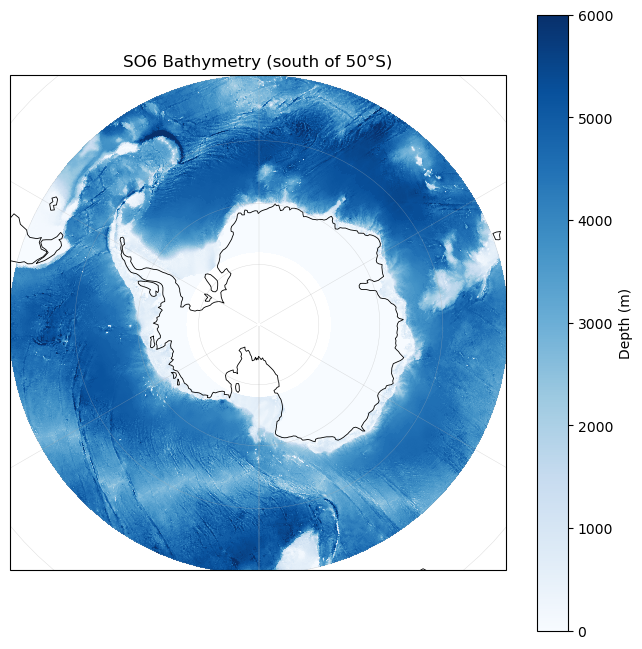

In [11]:
# Plot SO6 bathymetry

proj_data = ccrs.PlateCarree()
proj_map  = ccrs.SouthPolarStereo()

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj_map)

lon_min = float(bathym_so6.lon.min())
lon_max = float(bathym_so6.lon.max())
ax.set_extent([lon_min, lon_max, -90, -50], crs=proj_data)

bathym_so6.plot.pcolormesh(
    ax=ax, transform=proj_data, cmap='Blues',
    add_colorbar=True, add_labels=False,
    cbar_kwargs={'label': 'Depth (m)'},
)

try:
    ax.coastlines(resolution='110m', linewidth=0.6)
except Exception:
    pass

ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
ax.set_title('SO6 Bathymetry (south of 50°S)')
plt.show()

In [12]:
# Check coordinate ranges and determine common time period

print('SO6   YC  min/max:', float(U_so6.YC.min()), float(U_so6.YC.max()))
print('SO6   XG  min/max:', float(U_so6.XG.min()), float(U_so6.XG.max()))
print('BGOSE YC  min/max:', float(U_bgose.YC.min()), float(U_bgose.YC.max()))
print('BGOSE XG  min/max:', float(U_bgose.XG.min()), float(U_bgose.XG.max()))
print()

# Computed overlap
t_start = max(U_so6.time.values[0],  U_bgose.time.values[0])
t_end   = min(U_so6.time.values[-1], U_bgose.time.values[-1])
print(f'SO6   time: {str(U_so6.time.values[0])[:10]}  →  {str(U_so6.time.values[-1])[:10]}  ({U_so6.sizes["time"]} steps)')
print(f'BGOSE time: {str(U_bgose.time.values[0])[:10]}  →  {str(U_bgose.time.values[-1])[:10]}  ({U_bgose.sizes["time"]} steps)')
print(f'Computed overlap: {str(t_start)[:10]}  →  {str(t_end)[:10]}')

# Trim end to last complete calendar year common to both
t_end = np.datetime64('2021-12-01')
print(f'Using:            {str(t_start)[:10]}  →  {str(t_end)[:10]}')

SO6   YC  min/max: -77.98265075683594 -29.715316772460938
SO6   XG  min/max: 5.551115123125783e-17 359.8333435058594
BGOSE YC  min/max: -82.96875 85.80723571777344
BGOSE XG  min/max: 5.551115123125783e-17 359.83197021484375

SO6   time: 2013-01-01  →  2024-12-01  (144 steps)
BGOSE time: 2012-12-01  →  2022-02-01  (111 steps)
Computed overlap: 2013-01-01  →  2022-02-01
Using:            2013-01-01  →  2021-12-01


In [13]:
# Select the common time period for both simulations.
# No persist here — BGOSE6 raw arrays are global (~152 GB each) and persisting them
# upfront causes inter-worker TCP timeouts. With chunks={'time': 1}, each monthly
# chunk is read and interpolated independently, so file reads parallelize naturally
# as part of the de-stagger computation in the next cell.

UVEL_raw_so6   = U_so6['UVELMASS'].sel(time=slice(t_start, t_end))
VVEL_raw_so6   = V_so6['VVELMASS'].sel(time=slice(t_start, t_end))
UVEL_raw_bgose = U_bgose['UVELMASS'].sel(time=slice(t_start, t_end))
VVEL_raw_bgose = V_bgose['VVELMASS'].sel(time=slice(t_start, t_end))

print(f'SO6   UVELMASS: {dict(UVEL_raw_so6.sizes)}')
print(f'BGOSE UVELMASS: {dict(UVEL_raw_bgose.sizes)}')

SO6   UVELMASS: {'time': 108, 'Z': 52, 'YC': 588, 'XG': 2160}
BGOSE UVELMASS: {'time': 108, 'Z': 52, 'YC': 1566, 'XG': 2160}


In [14]:
# Along-slope velocity function
# (Defined early so it can be used in the method comparison cell below)

def along_slope_velocity(u: xr.DataArray,
                         v: xr.DataArray,
                         h: xr.DataArray,
                         lat_name: str = 'lat',
                         lon_name: str = 'lon',
                         R: float = 6371000.0,
                         eps: float = 1e-10) -> xr.DataArray:
    """
    Compute along-slope velocity component:
        u_along = (u * dy_h - v * dx_h) / sqrt((dx_h)^2 + (dy_h)^2)

    u, v : eastward and northward velocity [m/s] on (lat, lon)
    h    : bathymetry depth (positive downward)
    """

    u, v = xr.broadcast(u, h)[0], xr.broadcast(v, h)[0]

    dh_dlon = h.differentiate(lon_name, edge_order=2)
    dh_dlat = h.differentiate(lat_name, edge_order=2)

    deg2rad    = np.pi / 180.0
    lat_rad    = xr.apply_ufunc(np.deg2rad, h[lat_name])
    dxd_lambda = 1.0 / (R * xr.apply_ufunc(np.cos, lat_rad))
    dyd_phi    = 1.0 / R

    factor     = 180.0 / np.pi
    dh_dx      = dxd_lambda * dh_dlon * factor
    dh_dy      = dyd_phi    * dh_dlat * factor

    grad_norm  = xr.apply_ufunc(np.hypot, dh_dx, dh_dy, dask='allowed')
    numerator  = u * dh_dy - v * dh_dx
    denom      = xr.where(grad_norm < eps, np.nan, grad_norm)

    u_along    = numerator / denom
    u_along.name = 'u_along'
    u_along.attrs.update(
        long_name='along-slope velocity (tangent to isobaths, +90 deg rot of grad h)',
        units=getattr(u, 'units', 'm s-1'),
        notes='Computed with spherical metrics from lon/lat; masked where |grad h|~0.',
    )
    return u_along, grad_norm

In [15]:
# De-stagger both simulations to the tracer grid (YC, XC) via linear interpolation,
# then restrict to poleward of 50S and to the upper 1200m.
#
# .persist() after the interp materialises the interpolated results in distributed
# memory so each worker holds its own time-chunk data. Without this, subsequent
# operations (depth average, along-slope velocity) re-trigger the interpnd tasks
# and data locality collapses onto whichever worker ran the original interp.

n_depth = int(np.sum(U_so6.Z.values >= -1200.0))
print(f'Retaining {n_depth} of {U_so6.sizes["Z"]} depth levels  '
      f'(shallowest: {float(U_so6.Z[0]):.1f} m,  deepest retained: {float(U_so6.Z[n_depth-1]):.1f} m)')

# --- SO6 ---
XC_so6 = V_so6.coords['XC'].values
YC_so6 = U_so6.coords['YC'].values

UVEL_so6 = (UVEL_raw_so6
             .interp(XG=XC_so6, method='linear')
             .rename({'XG': 'lon', 'YC': 'lat', 'Z': 'depth'})
             .sel(lat=slice(None, -50.0))
             .isel(depth=slice(None, n_depth))
             .persist())

VVEL_so6 = (VVEL_raw_so6
             .interp(YG=YC_so6, method='linear')
             .rename({'YG': 'lat', 'XC': 'lon', 'Z': 'depth'})
             .sel(lat=slice(None, -50.0))
             .isel(depth=slice(None, n_depth))
             .persist())

# --- BGOSE6 ---
XC_bgose = V_bgose.coords['XC'].values
YC_bgose = U_bgose.coords['YC'].values

UVEL_bgose = (UVEL_raw_bgose
               .interp(XG=XC_bgose, method='linear')
               .rename({'XG': 'lon', 'YC': 'lat', 'Z': 'depth'})
               .sel(lat=slice(None, -50.0))
               .isel(depth=slice(None, n_depth))
               .persist())

VVEL_bgose = (VVEL_raw_bgose
               .interp(YG=YC_bgose, method='linear')
               .rename({'YG': 'lat', 'XC': 'lon', 'Z': 'depth'})
               .sel(lat=slice(None, -50.0))
               .isel(depth=slice(None, n_depth))
               .persist())

wait([UVEL_so6, VVEL_so6, UVEL_bgose, VVEL_bgose])
print('UVEL_so6:  ', dict(UVEL_so6.sizes))
print('UVEL_bgose:', dict(UVEL_bgose.sizes))
print('Interpolated data persisted across cluster.')

Retaining 37 of 52 depth levels  (shallowest: -2.1 m,  deepest retained: -1100.0 m)


2026-06-01 17:13:29,275 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:39267 -> tcp://127.0.0.1:41269
Traceback (most recent call last):
  File "/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TimeoutError: [Errno 110] Connection timed out

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/distributed/worker.py", line 1795, in get_data
    response = await comm.read(deserializers=serializers)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/hom

UVEL_so6:   {'time': 108, 'depth': 37, 'lat': 427, 'lon': 2160}
UVEL_bgose: {'time': 108, 'depth': 37, 'lat': 456, 'lon': 2160}
Interpolated data persisted across cluster.


In [16]:
# Compute 0-500m vertical averages for both simulations.
# Bathymetry is already on the same grid as UVEL/VVEL — no interpolation needed.
# Both simulations share the same Z grid, so thickness weights are computed once.

bathym_on_uv_so6   = bathym_so6
bathym_on_uv_bgose = bathym_bgose

z = UVEL_so6['depth'].values   # 1D, negative downward, restricted to 0-1200m
edges = np.empty(z.size + 1)
edges[1:-1] = 0.5 * (z[:-1] + z[1:])
edges[0]    = 0.0
edges[-1]   = z[-1] - (edges[-2] - z[-1])

top_clip = np.minimum(0.0,    edges[:-1])
bot_clip = np.maximum(-500.0, edges[1:])
thick    = np.maximum(0.0, top_clip - bot_clip)

w    = xr.DataArray(thick, coords={'depth': UVEL_so6.depth}, dims=('depth',))
wpos = w.where(w > 0, drop=True)

U_0_500_so6   = UVEL_so6.sel(depth=wpos.depth).weighted(wpos).mean('depth')
V_0_500_so6   = VVEL_so6.sel(depth=wpos.depth).weighted(wpos).mean('depth')
U_0_500_bgose = UVEL_bgose.sel(depth=wpos.depth).weighted(wpos).mean('depth')
V_0_500_bgose = VVEL_bgose.sel(depth=wpos.depth).weighted(wpos).mean('depth')

In [17]:
# Compute along-slope velocity for both simulations

u_along_0_500_so6,   topo_slope_so6   = along_slope_velocity(U_0_500_so6,   V_0_500_so6,   bathym_so6)
u_along_so6,         _                = along_slope_velocity(UVEL_so6,       VVEL_so6,       bathym_so6)

u_along_0_500_bgose, topo_slope_bgose = along_slope_velocity(U_0_500_bgose,  V_0_500_bgose,  bathym_bgose)
u_along_bgose,       _                = along_slope_velocity(UVEL_bgose,     VVEL_bgose,     bathym_bgose)

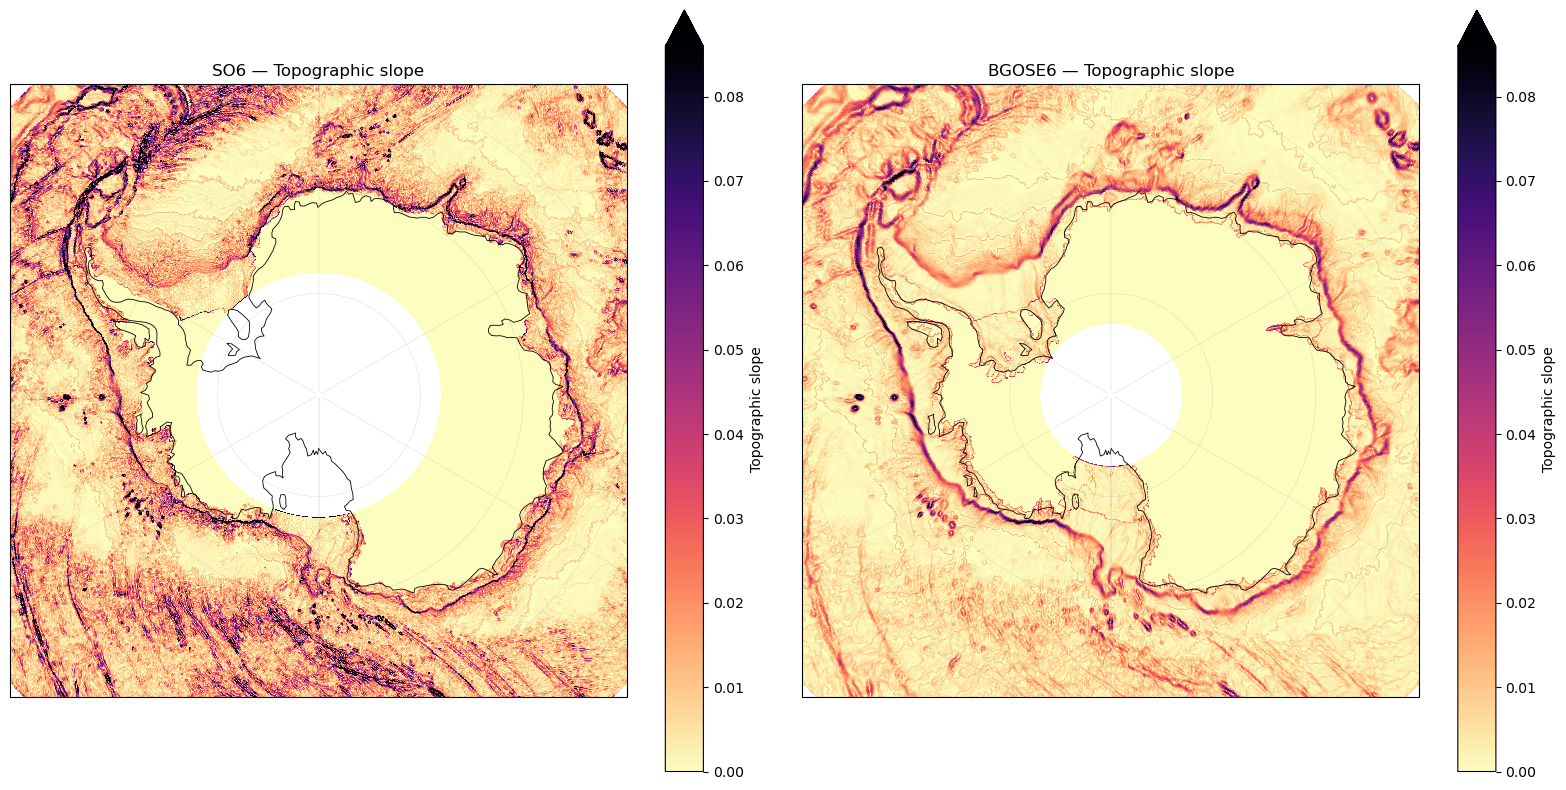

In [18]:
# Plot topographic slope side-by-side with shared color scale

proj_data = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                          subplot_kw={'projection': ccrs.SouthPolarStereo()})

slope_so6   = topo_slope_so6.clip(min=0)
slope_bgose = topo_slope_bgose.clip(min=0)
vmax = max(float(np.nanpercentile(slope_so6.values, 99)),
           float(np.nanpercentile(slope_bgose.values, 99)))
vmax = max(vmax, 1e-6)

for ax, da, title in zip(axes,
                          [slope_so6, slope_bgose],
                          ['SO6', 'BGOSE6']):
    ax.set_extent([float(da.lon.min()), float(da.lon.max()), -90, -60], crs=proj_data)
    da.plot.pcolormesh(ax=ax, transform=proj_data, cmap='magma_r',
                       vmin=0, vmax=vmax, add_colorbar=True, add_labels=False, shading='auto',
                       cbar_kwargs={'label': 'Topographic slope'})
    try:
        ax.coastlines(resolution='110m', linewidth=0.6)
    except Exception:
        pass
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
    ax.set_title(f'{title} — Topographic slope')

plt.tight_layout()
plt.show()

/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 21.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 22.60 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of

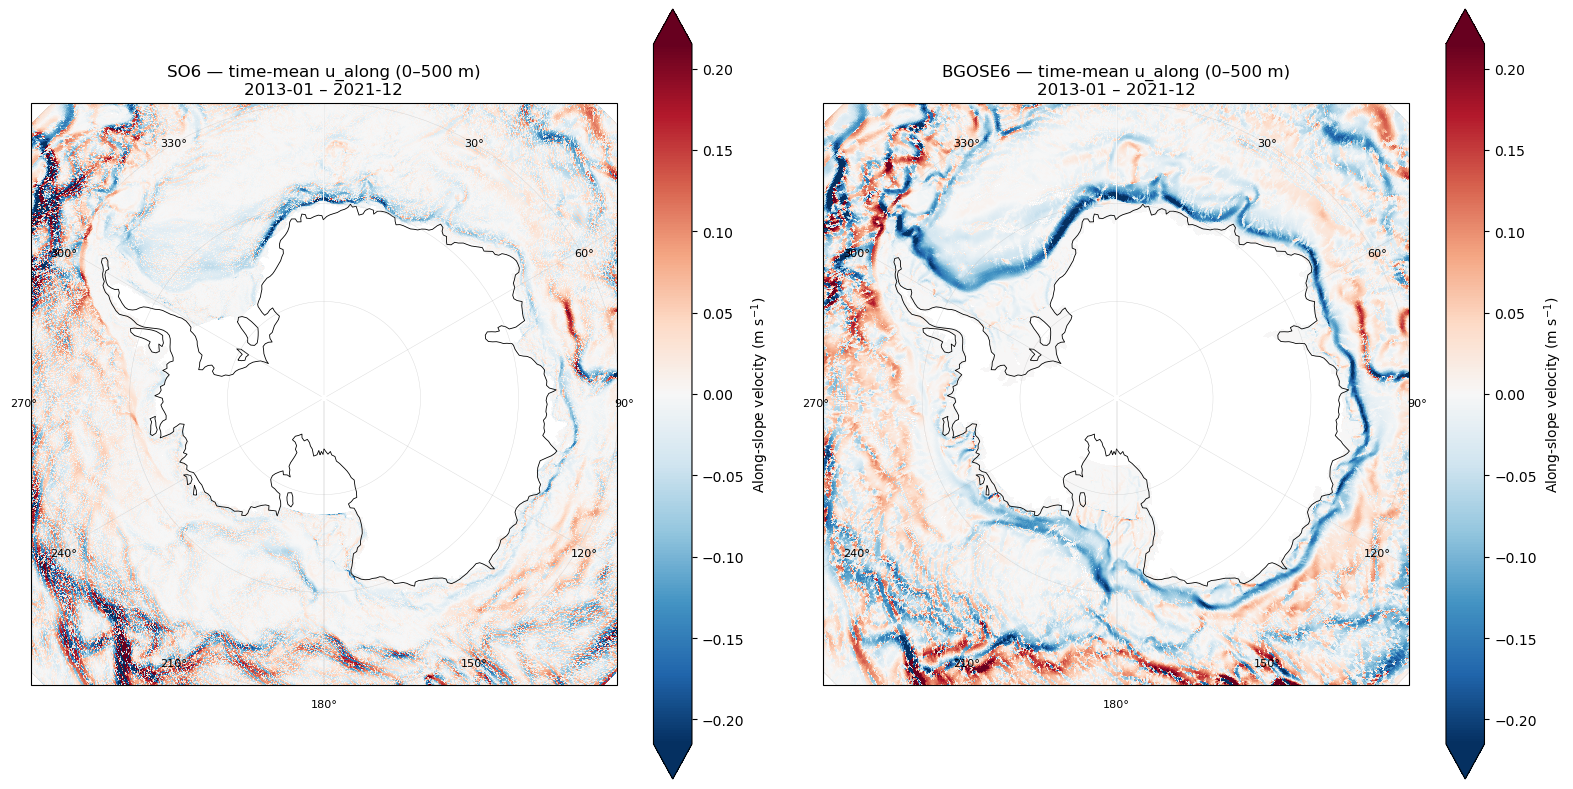

In [19]:
# Plot time-mean vertically averaged along-slope velocity (0-500m) side-by-side

da_so6   = u_along_0_500_so6.mean('time')
da_bgose = u_along_0_500_bgose.mean('time')

# Shared symmetric color scale
vmax = max(float(np.nanpercentile(np.abs(da_so6.values),   99)),
           float(np.nanpercentile(np.abs(da_bgose.values), 99)))
vmax = max(vmax, 1e-6)

t_label = f'{str(t_start)[:7]} – {str(t_end)[:7]}'
proj_data = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                          subplot_kw={'projection': ccrs.SouthPolarStereo()})

for ax, da, sim in zip(axes, [da_so6, da_bgose], ['SO6', 'BGOSE6']):
    lon_min = float(da.lon.min())
    lon_max = float(da.lon.max())
    ax.set_extent([lon_min, lon_max, -90, -60], crs=proj_data)
    da.plot.pcolormesh(ax=ax, transform=proj_data, cmap='RdBu_r',
                       vmin=-vmax, vmax=vmax, add_colorbar=True, add_labels=False, shading='auto',
                       cbar_kwargs={'label': 'Along-slope velocity (m s$^{-1}$)'})
    try:
        ax.coastlines(resolution='110m', linewidth=0.6)
    except Exception:
        pass
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
    for lam in np.arange(0, 360, 30):
        if lon_min <= lam <= lon_max:
            ax.text(lam, -59.5, f'{lam:.0f}°', transform=proj_data,
                    ha='center', va='top', fontsize=8, clip_on=False)
    ax.set_title(f'{sim} — time-mean u_along (0–500 m)\n{t_label}')

plt.tight_layout()
plt.show()

In [25]:
# Save outputs and close the dask cluster.
#
# 2D time-series (0-500m average): small enough for netCDF4.
# 3D time-series (full 0-1200m depth): saved as zarr — dask writes in parallel
# without netCDF4/HDF5 thread-safety collisions. Read back with xr.open_zarr().

out_dir = '/data/globus/zkaufman'
os.makedirs(out_dir, exist_ok=True)


def save_da_nc(da: xr.DataArray, fname: str, *,
               var_name: str = None,
               compress: bool = True,
               engine: str = 'netcdf4'):
    if var_name is not None:
        da = da.rename(var_name)
    elif da.name is None:
        da = da.rename('variable')
    encoding = {}
    if compress:
        encoding[da.name] = {'zlib': True, 'complevel': 4}
        for c in da.coords:
            encoding[c] = {'zlib': True, 'complevel': 4}
    ds = da.to_dataset()
    ds = ds.assign_attrs({
        **ds.attrs,
        'history': (
            datetime.now(timezone.utc).isoformat(timespec='seconds')
            + f': wrote with xarray (engine={engine})'
        ),
    })
    ds.to_netcdf(fname, engine=engine, encoding=encoding)
    print(f'Wrote {fname}')


def save_da_zarr(da: xr.DataArray, path: str, *, var_name: str = None):
    if var_name is not None:
        da = da.rename(var_name)
    elif da.name is None:
        da = da.rename('variable')
    ds = da.to_dataset()
    ds = ds.assign_attrs({
        **ds.attrs,
        'history': (
            datetime.now(timezone.utc).isoformat(timespec='seconds')
            + ': wrote with xarray/zarr'
        ),
    })
    ds.to_zarr(path, mode='w')
    print(f'Wrote {path}')


t_tag = f'{str(t_start)[:7].replace("-", "")}to{str(t_end)[:7].replace("-", "")}'

# --- SO6 ---
#save_da_nc(u_along_0_500_so6,
#           os.path.join(out_dir, f'u_along_0_500_SO6_{t_tag}_monthly.nc'),
#          var_name='u_along')
save_da_zarr(u_along_so6,
             os.path.join(out_dir, f'u_along_0_1200m_SO6_{t_tag}_monthly.zarr'),
             var_name='u_along')
save_da_nc(bathym_so6,
           os.path.join(out_dir, 'bathym_SO6.nc'),
           var_name='bathymetry')

# --- BGOSE6 ---
save_da_nc(u_along_0_500_bgose,
           os.path.join(out_dir, f'u_along_0_500_BGOSE6_{t_tag}_monthly.nc'),
           var_name='u_along')
save_da_zarr(u_along_bgose,
             os.path.join(out_dir, f'u_along_0_1200m_BGOSE6_{t_tag}_monthly.zarr'),
             var_name='u_along')
save_da_nc(bathym_bgose,
           os.path.join(out_dir, 'bathym_BGOSE6.nc'),
           var_name='bathymetry')

/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 21.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Wrote /data/globus/zkaufman/u_along_0_1200m_SO6_201301to202112_monthly.zarr
Wrote /data/globus/zkaufman/bathym_SO6.nc


/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 22.62 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Wrote /data/globus/zkaufman/u_along_0_500_BGOSE6_201301to202112_monthly.nc


/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 22.59 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Wrote /data/globus/zkaufman/u_along_0_1200m_BGOSE6_201301to202112_monthly.zarr
Wrote /data/globus/zkaufman/bathym_BGOSE6.nc


In [26]:
# Close dask cluster
client.close()
cluster.close()
print('Dask cluster closed.')

Dask cluster closed.
